In [65]:
import icepyx
import xopr
import geopandas as gpd

In [66]:
opr = xopr.opr_access.OPRConnection(cache_dir="/tmp")


antarctic_link = 'https://storage.googleapis.com/opr_stac/reference_geometry/measures_boundaries_4326.geojson'


gdf = gpd.read_file(antarctic_link)
# icesat_gdf = gpd.read_parquet('../data/antarctic_merged_icesat2_tracks.parquet')
# gdf = gdf.dissolve()


region = xopr.geometry.get_antarctic_regions(name='Thwaites', merge_regions=True)

stac_items = opr.query_frames(geometry=region)



Area is 192134.3 km^2, automatically applying 1km simplification tolerance
To disable simplification, set simplify_tolerance=0


In [67]:
stac_items['geometry']

stac_item_id
Data_20021212_01_001    LINESTRING (-101.94479 -75.10932, -101.96402 -...
Data_20021212_01_002    LINESTRING (-106.38255 -75.42308, -106.60324 -...
Data_20021212_01_005    LINESTRING (-112.69863 -74.82847, -112.65581 -...
Data_20021212_01_006    LINESTRING (-111.35763 -75.68575, -111.31784 -...
Data_20021212_01_007    LINESTRING (-107.39217 -75.62975, -107.35855 -...
                                              ...                        
Data_20181115_01_030    LINESTRING (-108.19042 -75.72062, -109.9338 -7...
Data_20181115_01_031    LINESTRING (-109.99997 -75.69213, -110.06747 -...
Data_20181115_01_032    LINESTRING (-108.87538 -75.88371, -108.76636 -...
Data_20181115_01_033    LINESTRING (-107.05315 -75.86843, -106.81241 -...
Data_20181115_01_034    LINESTRING (-105.24498 -75.80154, -105.13378 -...
Name: geometry, Length: 841, dtype: geometry

In [68]:
icesat_gdf = gpd.read_parquet('../data/antarctic_merged_icesat2_tracks_v2.parquet',bbox=region.bounds)
icesat_gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [69]:
test = stac_items['geometry'].intersection(icesat_gdf['geometry'])
# test[test != None]
test

stac_item_id
0                       None
1                       None
2                       None
3                       None
4                       None
                        ... 
Data_20181115_01_030    None
Data_20181115_01_031    None
Data_20181115_01_032    None
Data_20181115_01_033    None
Data_20181115_01_034    None
Length: 9130, dtype: geometry

In [74]:
%%time
stac_union = stac_items['geometry'].unary_union
stac_union = gpd.GeoSeries(stac_union)
stac_union

CPU times: user 45.6 ms, sys: 0 ns, total: 45.6 ms
Wall time: 46.3 ms


0    MULTILINESTRING ((-101.94479 -75.10932, -101.9...
dtype: geometry

In [81]:
stac_union = stac_union.clip(region)
# stac_union.plot()
stac_union.iloc[0]

In [78]:
# icesat_gdf = icesat_gdf.to_crs(4326)
# icesat_gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [82]:
%%time
x_points = icesat_gdf['geometry'].intersection(stac_union.iloc[0])

CPU times: user 5min 11s, sys: 0 ns, total: 5min 11s
Wall time: 5min 11s


In [83]:
x_points

0       MULTIPOINT Z ((-105.67702 -75.46911 0), (-105....
1                                      LINESTRING Z EMPTY
2                                      LINESTRING Z EMPTY
3                                      LINESTRING Z EMPTY
4                                      LINESTRING Z EMPTY
                              ...                        
8284                                   LINESTRING Z EMPTY
8285    MULTIPOINT Z ((-113.0663 -79.13089 0), (-110.8...
8286                                   LINESTRING Z EMPTY
8287                                   LINESTRING Z EMPTY
8288                                   LINESTRING Z EMPTY
Length: 8289, dtype: geometry

In [84]:
x_points_explode = x_points.explode()
x_points_explode

0       POINT Z (-105.67702 -75.46911 0)
0       POINT Z (-105.65092 -75.51144 0)
0       POINT Z (-105.78669 -75.28899 0)
0        POINT Z (-102.86337 -79.0223 0)
0       POINT Z (-105.47803 -75.78616 0)
                      ...               
8285    POINT Z (-113.06804 -79.13254 0)
8285    POINT Z (-110.81111 -76.53347 0)
8286                  LINESTRING Z EMPTY
8287                  LINESTRING Z EMPTY
8288                  LINESTRING Z EMPTY
Length: 59508, dtype: geometry

In [96]:
# x_points_explode.to_parquet('./data/x_points.parquet')
x_points_explode_gdf = x_points_explode.to_frame(name='geometry')
x_points_explode_gdf

,geometry
0,POINT Z (-105.67702 -75.46911 0)
0,POINT Z (-105.65092 -75.51144 0)
0,POINT Z (-105.78669 -75.28899 0)
0,POINT Z (-102.86337 -79.0223 0)
0,POINT Z (-105.47803 -75.78616 0)
...,...
8285,POINT Z (-113.06804 -79.13254 0)
8285,POINT Z (-110.81111 -76.53347 0)
8286,LINESTRING Z EMPTY
8287,LINESTRING Z EMPTY


In [102]:
# ~x_points_explode_gdf.is_empty
empty_mask = ~x_points_explode_gdf.is_empty

x_points_explode_gdf = x_points_explode_gdf[empty_mask]
x_points_explode_gdf.to_parquet('../data/x_points_explode.parquet')

In [103]:
x_points_explode_gdf

,geometry
0,POINT Z (-105.67702 -75.46911 0)
0,POINT Z (-105.65092 -75.51144 0)
0,POINT Z (-105.78669 -75.28899 0)
0,POINT Z (-102.86337 -79.0223 0)
0,POINT Z (-105.47803 -75.78616 0)
...,...
8285,POINT Z (-112.54547 -78.6178 0)
8285,POINT Z (-110.81107 -76.5334 0)
8285,POINT Z (-110.76905 -76.47431 0)
8285,POINT Z (-113.06804 -79.13254 0)


,geometry
0,POINT Z (-105.67702 -75.46911 0)
0,POINT Z (-105.65092 -75.51144 0)
0,POINT Z (-105.53906 -75.69025 0)
0,POINT Z (-102.86337 -79.0223 0)
0,POINT Z (-105.78669 -75.28899 0)
...,...
8286,POINT Z (-138.34695 -80.50176 0)
8287,POINT Z (-161.97952 -80.50209 0)
8287,POINT Z (-161.2918 -79.97462 0)
8288,POINT Z (174.40052 -80.4973 0)


In [26]:
stac_union_gdf = gpd.GeoDataFrame(crs="EPSG:4326", geometry=[stac_union])
stac_union_gdf

,geometry
0,"MULTILINESTRING ((-101.94479 -75.10932, -101.9..."


In [27]:
stac_union_gdf.to_parquet('../data/stac_union_gdf.parquet')

In [29]:
icesat_gdf.to_parquet('../data/icesat_gdf_gt.parquet')

In [45]:
from shapely.strtree import STRtree

In [48]:
%%time
result = gpd.sjoin(icesat_gdf, stac_union_gdf, how='inner', predicate='intersects')

CPU times: user 9.69 s, sys: 0 ns, total: 9.69 s
Wall time: 9.86 s


In [47]:
result

,id,Name,description,timestamp,begin,end,altitudeMode,tessellate,extrude,visibility,drawOrder,icon,layer,path,geometry,index_right
0,kml_plottp4d9a0f94_6663_4300_984e_d1c90b7ac500,5,,NaT,NaT,NaT,clampToGround,-1,0,1,NaN,NaN,antarcticaallorbits — Antarctica_repeat1_GT1L.kmz,/vsizip/C:/Users/shahi/Documents/englacial_hac...,"LINESTRING Z (-34.32914 -87.99608 0, -36.08493...",0
1,kml_plottp4aa2e424_239c_4f52_bd27_f78b3b841469,6,,NaT,NaT,NaT,clampToGround,-1,0,1,NaN,NaN,antarcticaallorbits — Antarctica_repeat1_GT1L.kmz,/vsizip/C:/Users/shahi/Documents/englacial_hac...,"LINESTRING Z (-58.92399 -87.98761 0, -60.66508...",0
2,kml_plottpedeaa40d_0d28_4e9a_b8b5_1e866262282e,7,,NaT,NaT,NaT,clampToGround,-1,0,1,NaN,NaN,antarcticaallorbits — Antarctica_repeat1_GT1L.kmz,/vsizip/C:/Users/shahi/Documents/englacial_hac...,"LINESTRING Z (-81.90123 -87.99137 0, -83.65053...",0
3,kml_plottp22ca4192_a6df_4953_a33e_bc34f039799c,8,,NaT,NaT,NaT,clampToGround,-1,0,1,NaN,NaN,antarcticaallorbits — Antarctica_repeat1_GT1L.kmz,/vsizip/C:/Users/shahi/Documents/englacial_hac...,"LINESTRING Z (-104.95421 -87.99499 0, -106.710...",0
4,kml_plottpa4b856ef_686e_432c_b2f2_d98d342e3aa9,9,,NaT,NaT,NaT,clampToGround,-1,0,1,NaN,NaN,antarcticaallorbits — Antarctica_repeat1_GT1L.kmz,/vsizip/C:/Users/shahi/Documents/englacial_hac...,"LINESTRING Z (-28.20886 -60.03173 0, -28.22176...",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8284,kml_plottpc2a476a1_6bef_4361_9461_cab27a16fc92,1383,,NaT,NaT,NaT,clampToGround,-1,0,1,NaN,NaN,antarcticaallorbits — Antarctica_repeat1_GT7.kmz,/vsizip/C:/Users/shahi/Documents/englacial_hac...,"LINESTRING Z (-177.19185 -87.99372 0, -178.974...",0
8285,kml_plottp9238bcc0_f35e_4089_903d_beb0f0c4c74c,1384,,NaT,NaT,NaT,clampToGround,-1,0,1,NaN,NaN,antarcticaallorbits — Antarctica_repeat1_GT7.kmz,/vsizip/C:/Users/shahi/Documents/englacial_hac...,"LINESTRING Z (-104.83507 -60.05553 0, -104.848...",0
8286,kml_plottp64fca788_d868_42c6_ad1c_0db71989da73,1385,,NaT,NaT,NaT,clampToGround,-1,0,1,NaN,NaN,antarcticaallorbits — Antarctica_repeat1_GT7.kmz,/vsizip/C:/Users/shahi/Documents/englacial_hac...,"LINESTRING Z (-128.45151 -60.02493 0, -128.464...",0
8287,kml_plottp167c6bce_ac8e_474f_8e89_18b8209c26da,1386,,NaT,NaT,NaT,clampToGround,-1,0,1,NaN,NaN,antarcticaallorbits — Antarctica_repeat1_GT7.kmz,/vsizip/C:/Users/shahi/Documents/englacial_hac...,"LINESTRING Z (-152.06958 -60.00124 0, -152.082...",0


In [54]:
tree = STRtree(icesat_gdf.geometry)
_, tree_idx = tree.query(stac_union_gdf['geometry'], predicate='intersects')

In [55]:
%%time
crossing_geoms = icesat_gdf.geometry.iloc[tree_idx]
points = crossing_geoms.intersection(stac_union_gdf['geometry'])

CPU times: user 69 ms, sys: 10.2 ms, total: 79.2 ms
Wall time: 88.4 ms


<Axes: >

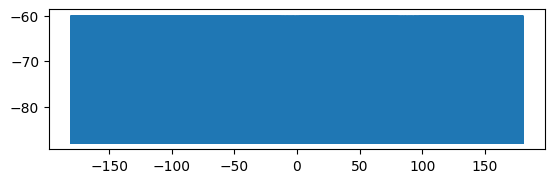

In [64]:
crossing_geoms.plot()

In [57]:
crossing_geoms

4428    LINESTRING Z (-79.14032 -60.06279 0, -79.15333...
1839    LINESTRING Z (-83.91912 -87.99831 0, -85.68062...
332     LINESTRING Z (-80.11943 -60.06112 0, -80.13233...
1169    LINESTRING Z (-80.37869 -60.06075 0, -80.39159...
7134    LINESTRING Z (-77.06461 -60.06089 0, -77.07762...
                              ...                        
5782    LINESTRING Z (-6.52059 -60.00058 0, -6.5337 -6...
6054    LINESTRING Z (-176.52826 -60.00029 0, -176.541...
5833    LINESTRING Z (-172.63617 -60.00079 0, -172.649...
5183    LINESTRING Z (-178.87156 -60.02732 0, -178.884...
5866    LINESTRING Z (-179.13091 -60.02698 0, -179.144...
Name: geometry, Length: 8235, dtype: geometry